<a href="https://colab.research.google.com/github/mikakia/AdvanceML_Final_Project/blob/main/blasto_ss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import torch
from torch import nn
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import random_split, DataLoader
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR


# Data Loading and EDA

## Before running:
Change shortcut to data.

For Ieva: 'content/drive/MyDrive/Data'

For Mika: '/content/drive/MyDrive/Advanced_ML/Final_Project/Data' <- It should work for both :)


## Load Data from google drive

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Change before running
ROOT_DIR = '/content/drive/MyDrive/Data'

blast_dir = os.path.join(ROOT_DIR, 'Blastocyst')
icm_dir = os.path.join(ROOT_DIR, 'GT_ICM')
te_dir = os.path.join(ROOT_DIR, 'GT_TE')
zp_dir = os.path.join(ROOT_DIR, 'GT_ZP')

Mounted at /content/drive


In [3]:
print(os.listdir('/content/drive/MyDrive/Data'))
#print(os.listdir('/content/drive/MyDrive/Advanced_ML'))

['Blastocyst', 'GT_ZP', 'GT_TE', 'GT_ICM']


## Creating a class for the data extending Dataset superclass

In [4]:
CLASS_NAMES = ['background', 'ICM', 'ZP', 'TE']


# Method to combine the masks into one
def masks_to_semantic(mask_list, background_label: int = 0):
  w, h = mask_list[0].shape
  semantic_mask = torch.full((h, w), fill_value=background_label, dtype=torch.int64)

  for class_idx, mask in enumerate(mask_list, start=1):
      semantic_mask[mask > 0] = class_idx

  return semantic_mask

# Creating Dataset class for our data
class BlastDataset(Dataset):
  MASK_NAMES = [' ICM', ' ZP', ' TE']

  def __init__(self, blast_dir, mask_dirs, size=(256, 256)):
    self.size = size
    self.image_transform = transforms.Compose([
        transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.ToTensor()
    ])
    self.mask_transform = transforms.Compose([
        transforms.Resize(size, interpolation=transforms.InterpolationMode.NEAREST)
    ])
    self.blast_dir = blast_dir
    self.mask_dirs = mask_dirs

    # Create masterlist of Blastocyst names
    self.filenames = sorted([
        f for f in os.listdir(blast_dir) if f.endswith('.BMP')
    ])



  # Returns number of images
  def __len__(self):
    return len(self.filenames)

  # Takes a blastocyst name and returns corresponding mask filename
  def _get_mask_name(self, blast_filename, mask_name):
    stem = os.path.splitext(blast_filename)[0] # Retrieves only image name
    return f"{stem}{mask_name}_Mask.bmp"

  # Fetch one sample
  def __getitem__(self, index):
    fname = self.filenames[index]
    image = self.image_transform(Image.open(os.path.join(self.blast_dir, fname)).convert('L'))

    masks = []
    for mask_name, mask_dir in zip(self.MASK_NAMES, self.mask_dirs):
      mask_fname = self._get_mask_name(fname, mask_name)
      mask = self.mask_transform(Image.open(os.path.join(mask_dir,mask_fname)).convert('L')) # Convert mask to grayscale
      masks.append(mask)

    # Convert to tensors here before passing to masks_to_semantic
    masks = [torch.from_numpy(np.array(m)).long() for m in masks]

    semantic_mask = masks_to_semantic(masks)

    return image, semantic_mask

## Explore the Data

### Check for missing values

In [5]:
# Checking if any masks are missing
dataset = BlastDataset(
    blast_dir=blast_dir,
    mask_dirs=[icm_dir, zp_dir, te_dir]
)

missing = []
for fname in dataset.filenames:
  for mask_name, mask_dir in zip(dataset.MASK_NAMES, dataset.mask_dirs):
    mask_fname = dataset._get_mask_name(fname, mask_name)
    full_path = os.path.join(mask_dir, mask_fname)
    if not os.path.exists(full_path):
      missing.append(full_path)

print(missing)

[]


### Visualizations

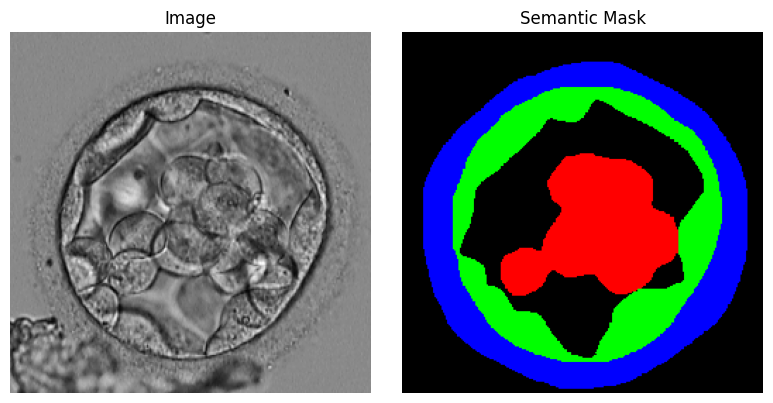

In [6]:
def semantic_mask_to_rgb(semantic_mask):
    # Define your color map: index = class label, value = (R, G, B)
    color_map = np.array([
        [0,   0,   0  ],  # 0 - background (black)
        [255, 0,   0  ],  # 1 - red
        [0,   0,   255],  # 2 - blue
        [0,   255, 0  ],  # 3 - green
    ], dtype=np.uint8)

    if hasattr(semantic_mask, "numpy"):
        semantic_mask = semantic_mask.numpy()

    return color_map[semantic_mask]  # (H, W) → (H, W, 3)


image, semantic_mask = dataset[0]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(image.squeeze(), cmap='grey')
axes[0].set_title('Image')

#for i, (mask, mask_name) in enumerate(zip(masks, [' ICM', ' ZP', ' TE'])):
#  axes[i+1].imshow(mask, cmap='gray')
#  axes[i+1].set_title(f'{mask_name} Mask')

axes[1].imshow(semantic_mask_to_rgb(semantic_mask))
axes[1].set_title('Semantic Mask')
for ax in axes:
  ax.axis('off')

plt.tight_layout()
plt.show()

### Check size

In [15]:
print("Image size:", image.shape)
print("Semantic mask size:", semantic_mask.shape)

Image size: torch.Size([1, 256, 256])
Semantic mask size: torch.Size([256, 256])


## DataLoaders

UNet works best with square inputs whose dimensions are divisible by 32 (because of the pooling layers)

In [16]:
total = len(dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_set, val_set, test_set = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=8, shuffle=False)

print(f"Train images: {len(train_set)} | Val images: {len(val_set)} | Test images: {len(test_set)}")

Train images: 174 | Val images: 37 | Test images: 38


In [7]:
class DoubleConv(nn.Module):
  # Two consecutive Conv -> BN -> ReLu blocks
  def __init__(self, in_channels: int, out_channels: int):
    super().__init__()
    self.double_conv = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )

  def forward(self, x):
    return self.double_conv(x)

class Down(nn.Module):
  # MaxPool then DoubleConv (encoder)

  def __init__(self, in_channels: int, out_channels: int):
    super().__init__()
    self.pool_conv = nn.Sequential(
        nn.MaxPool2d(2),
        DoubleConv(in_channels, out_channels)
    )

  def forward(self, x):
      return self.pool_conv(x)

class Up(nn.Module):
    # Bilinear upsample -> concat skip -> DoubleConv
  def __init__(self, in_channels: int, out_channels: int):
    super().__init__()

    # in_channels = channels from below + channels from skip connection
    self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
    self.conv = DoubleConv(in_channels, out_channels)

  def forward(self, x, skip):
    x = self.up(x) # upsamples input
    x = torch.cat([skip, x], dim=1)
    return self.conv(x)

class UNet(nn.Module):
  # in_channels = 1 for grayscale images
  # n_classes = 4 (bg + the 3 sections we are looking for)
  # base_filters = feature channels at encoder level (doubles each level)
  def __init__(self, in_channels: int=1, n_classes: int=4, base_filters: int =64):
    super().__init__()
    f = base_filters

    # Encoder
    self.enc1 = DoubleConv(in_channels, f) # 256 -> 256, 1 -> 64
    self.enc2 = Down(f, f*2) # 256 -> 128, 64 -> 128
    self.enc3 = Down(f*2, f*4) # 128 -> 64, 128 -> 256
    self.enc4 = Down(f*4, f*8) # 64 -> 32, 256 -> 512

    # Bottleneck
    self.bottleneck = Down(f*8, f*16) # 32 -> 16, 512 -> 1024

    #Decoder
    self.dec4 = Up(f*16 + f*8, f*8) # 1024 + 512 -> 512
    self.dec3 = Up(f*8 + f*4, f*4) # 512 + 256 -> 256
    self.dec2 = Up(f*4 + f*2, f*2) # 256 + 128 -> 128
    self.dec1 = Up(f*2 + f, f) # 128 + 64 -> 64

    # Classifier
    self.head = nn.Conv2d(f, n_classes, kernel_size=1)

  def forward(self,x):
    # Encoder (save skip connections)
    s1 = self.enc1(x)
    s2 = self.enc2(s1)
    s3 = self.enc3(s2)
    s4 = self.enc4(s3)

    # Bottleneck
    b = self.bottleneck(s4)

    # Decoder
    x = self.dec4(b, s4)
    x = self.dec3(x, s3)
    x = self.dec2(x, s2)
    x = self.dec1(x, s1)

    return self.head(x) # (B, num_classes, H, W) - raw logit

/tmp/ipykernel_664/4165751777.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


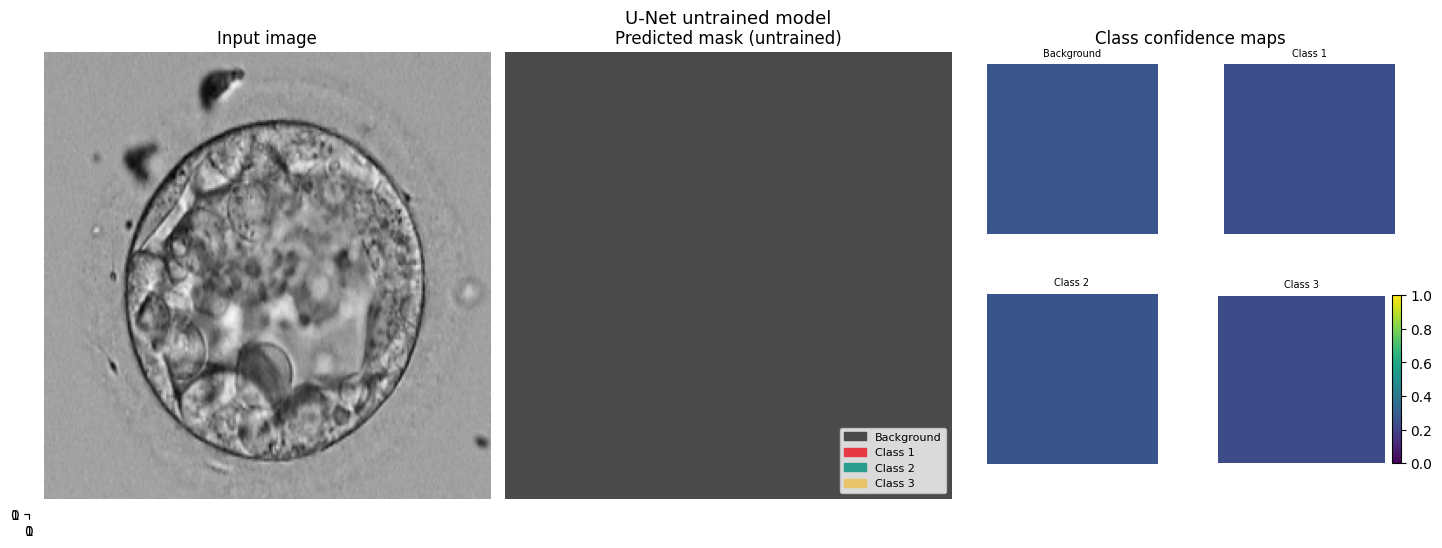

Output shape : torch.Size([1, 4, 256, 256])
Predicted classes present: [0]
Class pixel counts: {0: 65536, 1: 0, 2: 0, 3: 0}


In [8]:
import matplotlib.patches as mpatches

model = UNet(in_channels = 1, n_classes=4, base_filters=64)
model.eval()

image, semantic_mask = dataset[1]
batch = image.unsqueeze(0)

with torch.no_grad():
  logits = model(batch)
  probs = torch.softmax(logits, dim=1)
  pred = logits.argmax(dim=1)

pred_mask = pred.squeeze(0).numpy()

CLASS_COLORS = {
    0: ("Background", "#4a4a4a"),
    1: ("Class 1",    "#e63946"),
    2: ("Class 2",    "#2a9d8f"),
    3: ("Class 3",    "#e9c46a"),
}

# Build an RGB image from the predicted mask
h, w = pred_mask.shape
rgb = np.zeros((h, w, 3), dtype=np.uint8)
for cls_idx, (_, hex_color) in CLASS_COLORS.items():
    r, g, b = int(hex_color[1:3], 16), int(hex_color[3:5], 16), int(hex_color[5:7], 16)
    rgb[pred_mask == cls_idx] = [r, g, b]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Input image
axes[0].imshow(image.squeeze(0).numpy(), cmap="gray")
axes[0].set_title("Input image")
axes[0].axis("off")

# Predicted segmentation
axes[1].imshow(rgb)
axes[1].set_title("Predicted mask (untrained)")
axes[1].axis("off")
legend = [mpatches.Patch(color=col, label=name)
          for _, (name, col) in CLASS_COLORS.items()]
axes[1].legend(handles=legend, loc="lower right", fontsize=8)

# Per-class confidence maps
conf_grid = axes[2]
conf_grid.axis("off")
conf_grid.set_title("Class confidence maps")

inner = fig.add_axes([0, 0, 0, 0])  # dummy — we'll use GridSpec instead
fig.tight_layout()

# Replace axes[2] with a 2×2 sub-grid for the 4 confidence maps
gs = fig.add_gridspec(2, 2, left=0.68, right=0.98, top=0.9, bottom=0.1, hspace=0.35, wspace=0.3)
for cls_idx in range(4):
    ax = fig.add_subplot(gs[cls_idx // 2, cls_idx % 2])
    conf_map = probs[0, cls_idx].numpy()
    im = ax.imshow(conf_map, cmap="viridis", vmin=0, vmax=1)
    name, _ = CLASS_COLORS[cls_idx]
    ax.set_title(name, fontsize=7)
    ax.axis("off")

plt.colorbar(im, ax=fig.axes[-1], fraction=0.046, pad=0.04)
plt.suptitle("U-Net untrained model", fontsize=13, y=1.01)
plt.show()

print(f"Output shape : {logits.shape}")
print(f"Predicted classes present: {np.unique(pred_mask).tolist()}")
print(f"Class pixel counts: { {c: int((pred_mask == c).sum()) for c in range(4)} }")


In [9]:
# Metrics

class DiceLoss(nn.Module):
  # Smooth added to prevent division by zero
  def __init__(self, num_classes:int, smooth: float = 1e-6):
    super().__init__()
    self.num_classes = num_classes
    self.smooth = smooth

  def forward(self, logits, targets):
    # logits: (B, C, H, W), targets: (B, H, W) long
    probs = F.softmax(logits, dim=1) # Convert raw logits to probabilities
    targets_one_hot = F.one_hot(targets, self.num_classes) # (B, H, W, C)
    targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float() # (B, C, H, W)

    dims = (0, 2, 3) #average over batch, height, width
    intersection = (probs * targets_one_hot).sum(dims) # Element wise multiply probability with target
    cardinality = (probs + targets_one_hot).sum(dims) # Total predicted + total actual pixels per class

    dice_per_class = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
    return 1.0 - dice_per_class.mean() # Average over classes

class SegmentationLoss(nn.Module):
  # Weighted sum of CrossEntropy and Dice Loss
  def __init__(self, num_classes: int, ce_weight: float = 0.5, dice_weight: float = 0.5):
    super().__init__()
    self.ce = nn.CrossEntropyLoss()
    self.dice = DiceLoss(num_classes)
    self.ce_w = ce_weight
    self.dice_w = dice_weight

  def forward(self, logits, targets):
    return self.ce_w * self.ce(logits, targets) + self.dice_w * self.dice(logits, targets)

In [10]:
# Mean-IoU per class and overall
# preds: (B, H, W) long - predicted class indices
# targets: (B, H, W) long - ground-truth class indices
# Returns: dict with per-class IoU and mean_iou
def compute_iou(preds: torch.Tensor, targets: torch.Tensor, num_classes: int, class_names=None) -> dict:
  if class_names is None:
    class_names = [f"Class {i}" for i in range(num_classes)]

  iou_per_class = []
  for cls in range(num_classes):
    pred_mask = (preds == cls)
    target_mask = (targets == cls)
    intersection = (pred_mask & target_mask).sum().item()
    union = (pred_mask | target_mask).sum().item()
    iou = (intersection + 1e-6) / (union + 1e-6)
    iou_per_class.append(iou)

  result = {class_names[i]: v for i, v in enumerate(iou_per_class)}
  result["mean_iou"] = float(np.mean(iou_per_class))

  return result

# Training loop
def train_one_epoch(model, loader, criterion, optimizer, device):
  model.train()
  total_loss = 0.0

  for batch_idx, (images, masks) in enumerate(loader):
    images = images.to(device, dtype=torch.float32) # (B, 1, 256, 265)
    masks = masks.to(device, dtype=torch.long) # (B, 256, 256)

    optimizer.zero_grad()
    logits = model(images)
    loss = criterion(logits, masks)
    loss.backward()

    # Gradient clipping
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()
    total_loss += loss.item()

  return total_loss / len(loader)

# Validation loop
@torch.no_grad()
def validate(model, loader, criterion, device, num_classes: int, class_names=None):
  model.eval()
  total_loss = 0.0
  all_preds, all_targets = [], []

  for images, masks in loader:
    images = images.to(device, dtype=torch.float32) # (B, 1, 256, 265)
    masks = masks.to(device, dtype=torch.long) # (B, 256, 256)

    logits = model(images)
    loss = criterion(logits, masks)
    total_loss += loss.item()

    preds = logits.argmax(dim=1)
    all_preds.append(preds.cpu())
    all_targets.append(masks.cpu())

  all_preds = torch.cat(all_preds, dim=0)
  all_targets = torch.cat(all_targets, dim=0)

  metrics = compute_iou(all_preds, all_targets, num_classes, class_names = class_names)
  metrics['val_loss'] = total_loss / len(loader)
  return metrics

In [11]:
def train(
    dataset,
    *,
    num_classes: int = 4,
    class_names: list[str] = None,
    val_split: float = 0.2,
    epochs: int = 50,
    batch_size: int = 8,
    lr: float = 1e-4,
    base_filters: int = 64,
    save_path: str = 'best_unet.pth',
    device: str | None = None
):
  if device is None:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
  print(f"Using device: {device}")

  # Data split
  n_val = int(len(dataset) * val_split)
  n_train = len(dataset) - n_val
  train_ds, val_ds = random_split(
      dataset, [n_train, n_val],
      generator=torch.Generator().manual_seed(42)
  )

  train_loader = DataLoader(train_ds, batch_size = batch_size, shuffle=True, num_workers=4, pin_memory=True)
  val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

  # Model, loss, optimizer
  model = UNet(in_channels=1, n_classes=num_classes, base_filters=base_filters).to(device)
  criterion = SegmentationLoss(num_classes).to(device)
  optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
  scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr/100)

  total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
  print(f"Total number of trainable parameters: {total_params}")

  # Training loop

  best_miou = 0.0

  for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate(model, val_loader, criterion, device, num_classes, class_names=None)
    scheduler.step()

    miou = val_metrics['mean_iou']
    print(
        f"Epoch {epoch:3d}/{epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_metrics['val_loss']:.4f} | "
        f"mIoU: {miou:.4f}"
    )

    # Print per-class IoU every 10 epochs
    if epoch % 10 == 0:
      for name, iou in val_metrics.items():
        if name != 'mean_iou':
          print(f"  {name}: {iou:.4f}")

    # Save best model
    if miou > best_miou:
      best_miou = miou
      torch.save({"epoch": epoch, "model_state": model.state_dict(),
                  "miou": miou}, save_path)

      print(f"New bes model mIoU {miou:.4f} - saved to {save_path}")
  print(f"\nTraining complete. Best mIoU: {best_miou:.4f}")
  return model

# Inference helper, allows to run just one image or batch
@torch.no_grad()
def predict(model, image_tensor: torch.Tensor, device: str = "cpu") -> torch.Tensor:
  model.eval()
  if image_tensor.dim() == 3:
    image_tensor = image_tensor.unsqueeze(0) # Add batch dimension if one image

  image_tensor = image_tensor.to(device, dtype=torch.float32)
  logits = model(image_tensor)
  preds = logits.argmax(dim=1)
  return preds.squeeze(0) if preds.size(0) == 1 else preds

In [13]:
model = train(
    dataset,
    num_classes = 4,
    class_names = CLASS_NAMES,
    val_split = 0.2,
    epochs = 50,
    batch_size = 8,
    lr = 1e-4,
    base_filters = 64,
    save_path = 'best_unet.pth'
)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Total number of trainable parameters: 31383876


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch   1/50 | Train loss: 0.7600 | Val loss: 0.8938 | mIoU: 0.1659
New bes model mIoU 0.1659 - saved to best_unet.pth
Epoch   2/50 | Train loss: 0.5654 | Val loss: 0.7183 | mIoU: 0.4175
New bes model mIoU 0.4175 - saved to best_unet.pth
Epoch   3/50 | Train loss: 0.4962 | Val loss: 0.4815 | mIoU: 0.6802
New bes model mIoU 0.6802 - saved to best_unet.pth
Epoch   4/50 | Train loss: 0.4529 | Val loss: 0.4485 | mIoU: 0.7162
New bes model mIoU 0.7162 - saved to best_unet.pth
Epoch   5/50 | Train loss: 0.4190 | Val loss: 0.4789 | mIoU: 0.6604
Epoch   6/50 | Train loss: 0.3836 | Val loss: 0.3948 | mIoU: 0.7420
New bes model mIoU 0.7420 - saved to best_unet.pth
Epoch   7/50 | Train loss: 0.3574 | Val loss: 0.4042 | mIoU: 0.7245
Epoch   8/50 | Train loss: 0.3319 | Val loss: 0.3858 | mIoU: 0.7327
Epoch   9/50 | Train loss: 0.3099 | Val loss: 0.3515 | mIoU: 0.7579
New bes model mIoU 0.7579 - saved to best_unet.pth
Epoch  10/50 | Train loss: 0.2847 | Val loss: 0.3308 | mIoU: 0.7712
  Class 0: 0.8

In [15]:
# 1. Rebuild the model architecture (must match what you trained)
model = UNet(in_channels=1, n_classes=4, base_filters=64)

# 2. Load the saved weights
checkpoint = torch.load("best_unet.pth", map_location="cpu")
model.load_state_dict(checkpoint["model_state"])
print(f"Loaded checkpoint from epoch {checkpoint['epoch']} with mIoU {checkpoint['miou']:.4f}")

# 3. Grab an image and predict
image, mask = dataset[0]              # or load your own image tensor
pred_mask = predict(model, image)     # (256, 256) class indices

print(pred_mask.shape)
print(pred_mask.unique())             # which classes were predicted

Loaded checkpoint from epoch 25 with mIoU 0.7985
torch.Size([256, 256])
tensor([0, 1, 2, 3])


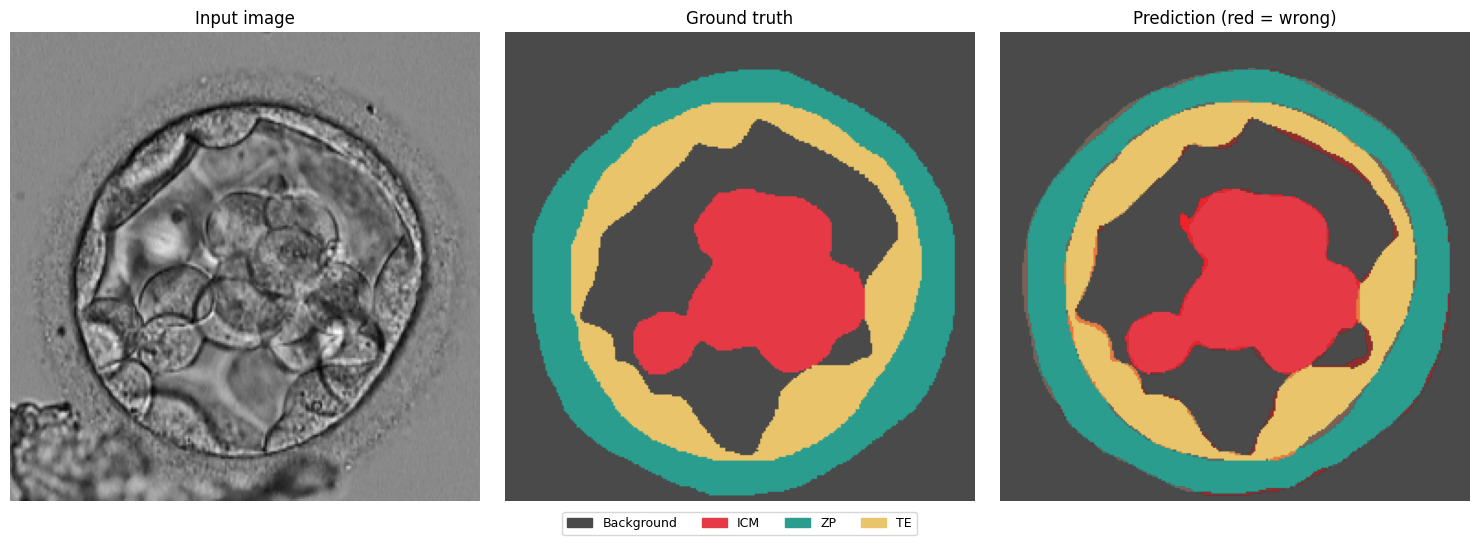

In [23]:
CLASS_COLORS = {
    0: ("Background", "#4a4a4a"),
    1: ("ICM",     "#e63946"),
    2: ("ZP",      "#2a9d8f"),
    3: ("TE",     "#e9c46a"),
}

def visualize_prediction(image, pred_mask, gt_mask=None, class_colors=CLASS_COLORS):
    """
    Args:
        image:     (1, 256, 256) float tensor
        pred_mask: (256, 256)    long tensor  — from predict()
        gt_mask:   (256, 256)    long tensor  — class indices
                   (4, 256, 256) float tensor — one-hot, converted automatically
    """

    # Convert one-hot gt_mask to class indices if needed
    if gt_mask is not None and gt_mask.dim() == 3:
        gt_mask = gt_mask.argmax(dim=0)   # (4, 256, 256) → (256, 256)

    def mask_to_rgb(mask_np):
        h, w = mask_np.shape
        rgb = np.zeros((h, w, 3), dtype=np.uint8)
        for cls_idx, (_, hex_color) in class_colors.items():
            r, g, b = int(hex_color[1:3], 16), int(hex_color[3:5], 16), int(hex_color[5:7], 16)
            rgb[mask_np == cls_idx] = [r, g, b]
        return rgb

    pred_np = pred_mask.cpu().numpy()
    n_cols  = 3 if gt_mask is not None else 2
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))

    # Input image
    axes[0].imshow(image.squeeze(0).cpu().numpy(), cmap="gray")
    axes[0].set_title("Input image")
    axes[0].axis("off")

    # Ground truth
    if gt_mask is not None:
        gt_np = gt_mask.cpu().numpy()
        axes[1].imshow(mask_to_rgb(gt_np))
        axes[1].set_title("Ground truth")
        axes[1].axis("off")

    # Prediction
    ax_pred = axes[2] if gt_mask is not None else axes[1]
    ax_pred.imshow(mask_to_rgb(pred_np))
    ax_pred.set_title("Prediction")
    ax_pred.axis("off")

    # Overlay: highlight disagreements in red
    if gt_mask is not None:
        wrong = (pred_np != gt_np).astype(np.uint8) * 255
        overlay = np.zeros((*pred_np.shape, 4), dtype=np.uint8)  # RGBA
        overlay[..., 0] = wrong    # red channel
        overlay[..., 3] = wrong    # alpha channel
        ax_pred.imshow(overlay, alpha=0.4)
        ax_pred.set_title(f"Prediction (red = wrong)")

    # Shared legend
    legend = [mpatches.Patch(color=col, label=name)
              for _, (name, col) in class_colors.items()]
    fig.legend(handles=legend, loc="lower center", ncol=4,
               bbox_to_anchor=(0.5, -0.05), fontsize=9)

    plt.tight_layout()
    plt.savefig("prediction_vs_gt.png", dpi=150, bbox_inches="tight")
    plt.show()


# ── Usage ─────────────────────────────────────────────────────────────────────
image, gt_mask = dataset[0]
pred_mask = predict(model, image)
visualize_prediction(image, pred_mask, gt_mask)